## **Data Analysis on Q5**

## **Q3**

## **Data Cleaning**

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [31]:
statewise_df = pd.read_csv('../data/raw/India-Tourism-Statistics-statewise_2019-2020_domestic_foreign.csv')

statewise = statewise_df[statewise_df['States/UTs'] != 'Grand Total'].copy()
statewise.columns = ['s_no', 'state', 'domestic_2019', 'foreign_2019', 
                     'domestic_2020', 'foreign_2020', 'growth_domestic', 'growth_foreign']

statewise['growth_domestic'] = pd.to_numeric(statewise['growth_domestic'], errors='coerce')
statewise['growth_foreign'] = pd.to_numeric(statewise['growth_foreign'], errors='coerce')

statewise['total_2019'] = statewise['domestic_2019'] + statewise['foreign_2019']
statewise['foreign_share'] = (statewise['foreign_2019'] / statewise['total_2019']) * 100

def normalize(col):
    return (col - col.min()) / (col.max() - col.min())

statewise['domestic_norm'] = normalize(statewise['domestic_2019'])
statewise['foreign_share_norm'] = normalize(statewise['foreign_share'])
statewise['gap_potential'] = statewise['domestic_norm'] * (1 - statewise['foreign_share_norm'])

In [33]:
monuments_df = pd.read_csv('../data/raw/India-Tourism-Statistics-2021-monuments.csv')
monument_totals = monuments_df[monuments_df['Name of the Monument'] == 'Total'].copy()

monument_totals.columns = ['circle', 'name', 'dom_mon_2019', 'for_mon_2019',
                           'dom_mon_2020', 'for_mon_2020', 'growth_dom_mon', 'growth_for_mon']

for col in ['dom_mon_2019', 'for_mon_2019', 'dom_mon_2020', 'for_mon_2020']:
    monument_totals[col] = pd.to_numeric(monument_totals[col], errors='coerce')

circle_map = {
    'Agra': 'Uttar Pradesh', 'Lucknow': 'Uttar Pradesh', 'Jhansi': 'Uttar Pradesh', 'Sarnath': 'Uttar Pradesh',
    'Thrissur': 'Kerala', 'Chennai': 'Tamil Nadu', 'Tiruchirappalli': 'Tamil Nadu',
    'Bhopal': 'Madhya Pradesh', 'Jabalpur': 'Madhya Pradesh',
    'Dharwad': 'Karnataka', 'Hampi': 'Karnataka', 'Banglore': 'Karnataka',
    'Raiganj': 'West Bengal', 'Kolkata': 'West Bengal',
    'Rajkot': 'Gujarat', 'Vadodara': 'Gujarat',
    'Bhubaneswar': 'Odisha',
    'Aurangabad': 'Maharashtra', 'Mumbai': 'Maharashtra', 'Nagpur': 'Maharashtra',
    'Chandigarh': 'Chandigarh', 'Delhi': 'Delhi', 'Guwahati': 'Assam', 'Goa': 'Goa',
    'Hyderabad': 'Telengana', 'Jaipur': 'Rajasthan', 'Jodhpur': 'Rajasthan',
    'Leh': 'Ladakh', 'Patna': 'Bihar', 'Raipur': 'Chhattisgarh',
    'Shimla': 'Himachal Pradesh', 'Srinagar': 'Jammu & Kashmir', 'Amaravati': 'Andhra Pradesh'
}

monument_totals['state'] = monument_totals['circle'].map(circle_map)

monument_by_state = monument_totals.groupby('state').agg({
    'dom_mon_2019': 'sum', 'for_mon_2019': 'sum',
    'dom_mon_2020': 'sum', 'for_mon_2020': 'sum'
}).reset_index()

monument_by_state.columns = ['state', 'monument_domestic_2019', 'monument_foreign_2019',
                              'monument_domestic_2020', 'monument_foreign_2020']

In [6]:
statewise_df.head()

,S. No.,States/UTs,Domestic -2019,Foreign - 2019,Domestic -2020,Foreign - 2020,Growth rate - DTV 2020/19,Growth rate - FTV 2020/19
0,1,A&N Island,505398,16206,191207,5412,-62.17,-66.6
1,2,Andhra Pradesh,237051508,280356,70828590,67591,-70.12,-75.89
2,3,Arunachal Pradesh,555639,7825,42871,961,-92.28,-87.72
3,4,Assam,5447805,26878,1266898,7285,-76.74,-72.9
4,5,Bihar,33990038,1093141,5638024,308080,-83.41,-71.82


In [7]:
reason_df.head(10)

,Region,Country of Nationality,Arrivals (in numbers),Business and Professional(%),Leisure Holiday and Recreation(%),Medical(%),Indian Diaspora(%),Others(%)
0,North America,CANADA,351859,4.82,50.94,0.14,21.49,22.61
1,North America,UNITED STATES,1512032,11.24,38.56,0.08,29.48,20.64
2,North America,OTHERS,1,0.00,100.00,0.00,0.00,0.00
3,North America,Total,1863892,10.03,40.90,0.09,27.97,21.01
4,Central & South America,ARGENTINA,12844,14.69,78.60,0.08,1.25,5.38
5,Central & South America,BRAZIL,25422,29.16,58.01,0.06,1.80,10.96
6,Central & South America,MEXICO,20766,18.23,72.18,0.06,1.67,7.86
7,Central & South America,OTHERS,39894,17.38,59.64,0.32,5.96,16.70
8,Central & South America,Total,98926,20.24,64.31,0.17,3.38,11.90
9,Western Europe,AUSTRIA,32332,22.65,47.92,0.09,16.83,12.51


In [34]:
# merge
statewise = statewise.merge(monument_by_state, on='state', how='left')

# fill missing monuments with 0
statewise['monument_domestic_2019'] = statewise['monument_domestic_2019'].fillna(0)
statewise['monument_foreign_2019'] = statewise['monument_foreign_2019'].fillna(0)
statewise['monument_domestic_2020'] = statewise['monument_domestic_2020'].fillna(0)
statewise['monument_foreign_2020'] = statewise['monument_foreign_2020'].fillna(0)

# clean state names
statewise['state'] = statewise['state'].str.strip()

# resilience
statewise['resilience_domestic'] = statewise['growth_domestic'] + 100
statewise['resilience_norm'] = normalize(statewise['resilience_domestic'])

# monument norm
statewise['monument_domestic_norm'] = normalize(statewise['monument_domestic_2019'])

# final scores
statewise['medical_potential'] = (
    statewise['domestic_norm'] * 0.4 +
    (1 - statewise['foreign_share_norm']) * 0.3 +
    statewise['resilience_norm'] * 0.3
)

statewise['niche_potential'] = (
    statewise['monument_domestic_norm'] * 0.35 +
    statewise['domestic_norm'] * 0.25 +
    statewise['resilience_norm'] * 0.25 +
    (1 - statewise['foreign_share_norm']) * 0.15
)

statewise['overall_potential'] = (statewise['medical_potential'] + statewise['niche_potential']) / 2

In [35]:
top10 = statewise.nlargest(10, 'overall_potential')[['state', 'domestic_2019', 'foreign_2019',
    'foreign_share', 'growth_domestic', 'medical_potential', 'niche_potential', 'overall_potential']]

print(top10.round(3).to_string(index=False))

         state  domestic_2019  foreign_2019  foreign_share  growth_domestic  medical_potential  niche_potential  overall_potential
 Uttar Pradesh      535855162       4745181          0.878           -83.93              0.757            0.801              0.779
    Tamil Nadu      494865257       6866327          1.369           -71.58              0.780            0.478              0.629
   Maharashtra      149294703       5528704          3.571           -73.72              0.486            0.583              0.535
     Telengana       83035894        323326          0.388           -51.83              0.578            0.479              0.529
     Karnataka      227934714        608754          0.266           -66.02              0.620            0.382              0.501
Andhra Pradesh      237051508        280356          0.118           -70.12              0.609            0.371              0.490
    Puducherry        1713248        149919          8.046           -34.92        

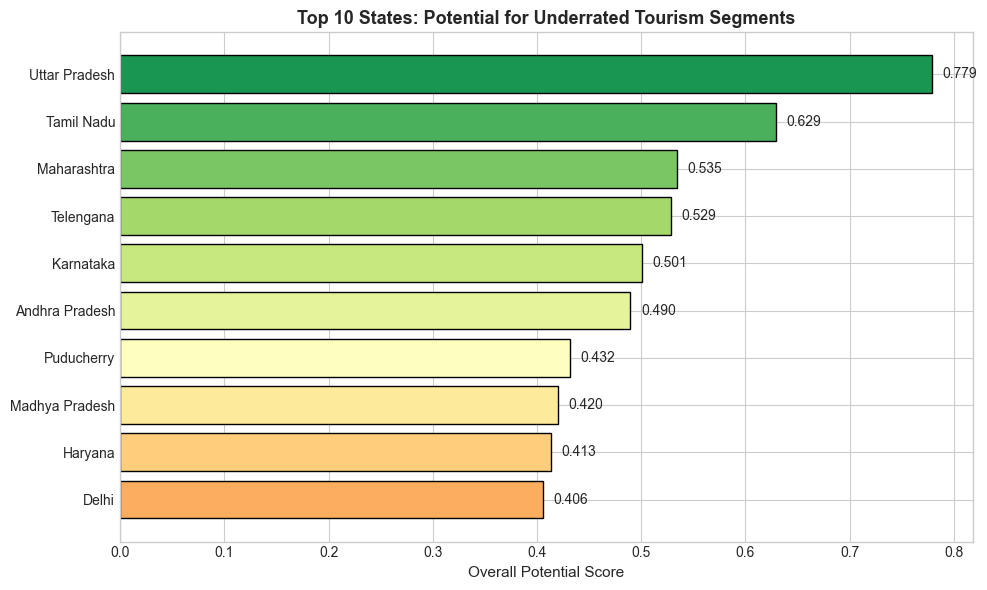

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))

top10_plot = statewise.nlargest(10, 'overall_potential').sort_values('overall_potential')
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, 10))

bars = ax.barh(top10_plot['state'], top10_plot['overall_potential'], color=colors, edgecolor='black')
ax.set_xlabel('Overall Potential Score', fontsize=11)
ax.set_title('Top 10 States: Potential for Underrated Tourism Segments', fontsize=13, fontweight='bold')

for bar, val in zip(bars, top10_plot['overall_potential']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/q3_top10_states.png', dpi=150, bbox_inches='tight')
plt.show()

## **Q1**

In [39]:
reason_df = pd.read_csv('../data/raw/India-Tourism-Statistics-2019_region-and-reason.csv')
print(reason_df.shape)
print(reason_df.columns.tolist())
print(reason_df.head(10))

(84, 8)
['Region', 'Country of Nationality', 'Arrivals (in numbers)', 'Business and Professional(%)', 'Leisure Holiday and Recreation(%)', 'Medical(%)', 'Indian Diaspora(%)', 'Others(%)']
                    Region Country of Nationality  Arrivals (in numbers)  \
0            North America                 CANADA                 351859   
1            North America          UNITED STATES                1512032   
2            North America                 OTHERS                      1   
3            North America                  Total                1863892   
4  Central & South America              ARGENTINA                  12844   
5  Central & South America                 BRAZIL                  25422   
6  Central & South America                 MEXICO                  20766   
7  Central & South America                 OTHERS                  39894   
8  Central & South America                  Total                  98926   
9           Western Europe                AUSTRIA   

In [40]:
# extract grand total for overall India numbers
grand_total = reason_df[reason_df['Region'] == 'Grand Total'].iloc[0]
print("Overall India purpose distribution:")
print(f"Business: {grand_total['Business and Professional(%)']}%")
print(f"Leisure: {grand_total['Leisure Holiday and Recreation(%)']}%")
print(f"Medical: {grand_total['Medical(%)']}%")
print(f"Diaspora: {grand_total['Indian Diaspora(%)']}%")
print(f"Others: {grand_total['Others(%)']}%")

Overall India purpose distribution:
Business: 14.69%
Leisure: 57.06%
Medical: 6.38%
Diaspora: 12.67%
Others: 9.2%


In [41]:
reason_totals = reason_df[(reason_df['Country of Nationality'] == 'Total') & 
                        (reason_df['Region'] != 'Grand Total')].copy()

reason_totals.columns = ['region', 'country', 'arrivals', 'business_pct', 'leisure_pct',
                         'medical_pct', 'diaspora_pct', 'others_pct']

for col in ['arrivals', 'business_pct', 'leisure_pct', 'medical_pct', 'diaspora_pct', 'others_pct']:
    reason_totals[col] = pd.to_numeric(reason_totals[col], errors='coerce')

print("\nRegional breakdown of underrated segments:")
print(reason_totals[['region', 'medical_pct', 'others_pct', 'arrivals']].to_string(index=False))


Regional breakdown of underrated segments:
                 region  medical_pct  others_pct  arrivals
          North America         0.09       21.01   1863892
Central & South America         0.17       11.90     98926
         Western Europe         0.10       16.74   2178441
         Eastern Europe         5.15        9.21    456481
                 Africa        14.46       28.19    362308
              West Asia        22.38       15.26    431943
             South Asia        13.08       11.62   3375819
        South East Asia         0.64       22.02    930540
              East Asia         0.05        9.37    782225
            Australasia         0.50       14.93    438939
